<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Imports</span>
</div>

In [1]:
# !pip install -r requirements.txt

In [2]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.7.1+cu118
11.8
True
NVIDIA GeForce RTX 5070 Ti Laptop GPU


c:\Users\kesho\OneDrive\Documents\topic_pro\project_topic\Lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5070 Ti Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5070 Ti Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [3]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, GlobalMaxPool1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set Style for Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
color_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
print(" All libraries imported successfully!")

 All libraries imported successfully!


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kesho\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kesho\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kesho\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;"> Load the dataset
</span>
</div>

In [5]:
df = pd.read_csv('ai-Human/AI_Human.csv')

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nLast 5 rows:")
display(df.tail())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics for 'generated' column:")
print(df['generated'].describe())

DATASET INFORMATION
Dataset Shape: (487235, 2)

Columns: ['text', 'generated']

First 5 rows:


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0



Last 5 rows:


,text,generated
487230,Tie Face on Mars is really just a big misunder...,0.0
487231,The whole purpose of democracy is to create a ...,0.0
487232,I firmly believe that governments worldwide sh...,1.0
487233,I DFN't agree with this decision because a LFT...,0.0
487234,"Richard Non, Jimmy Carter, and Bob Dole and ot...",0.0



Data Types:
text             str
generated    float64
dtype: object

Missing Values:
text         0
generated    0
dtype: int64

Basic Statistics for 'generated' column:
count    487235.000000
mean          0.372383
std           0.483440
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: generated, dtype: float64


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Preparing and understanding the data</span>
</div>

In [6]:
print("=" * 60)
print("ANALYZING 'generated' COLUMN")
print("=" * 60)

unique_values = df['generated'].unique()
print(f"Unique values in 'generated': {unique_values}")
print(f"Data type of 'generated': {df['generated'].dtype}")

print(f"\nValue counts:")
print(df['generated'].value_counts())
print(f"\nValue counts (normalized):")
print(df['generated'].value_counts(normalize=True))

df['label'] = df['generated'].apply(lambda x: 'AI' if x == 1.0 else 'Human')
print(f"\nNew 'label' column created from 'generated'")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"\nLabel distribution (%):\n{df['label'].value_counts(normalize=True) * 100}")

print(f"\nChecking for inconsistencies:")
print(f"Number of rows where generated is 0.0: {(df['generated'] == 0.0).sum()}")
print(f"Number of rows where generated is 1.0: {(df['generated'] == 1.0).sum()}")
print(f"Total rows: {len(df)}")

ANALYZING 'generated' COLUMN
Unique values in 'generated': [0. 1.]
Data type of 'generated': float64

Value counts:
generated
0.0    305797
1.0    181438
Name: count, dtype: int64

Value counts (normalized):
generated
0.0    0.627617
1.0    0.372383
Name: proportion, dtype: float64

New 'label' column created from 'generated'
Label distribution:
label
Human    305797
AI       181438
Name: count, dtype: int64

Label distribution (%):
label
Human    62.761706
AI       37.238294
Name: proportion, dtype: float64

Checking for inconsistencies:
Number of rows where generated is 0.0: 305797
Number of rows where generated is 1.0: 181438
Total rows: 487235


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Exploratory Data Analysis</span>
</div>

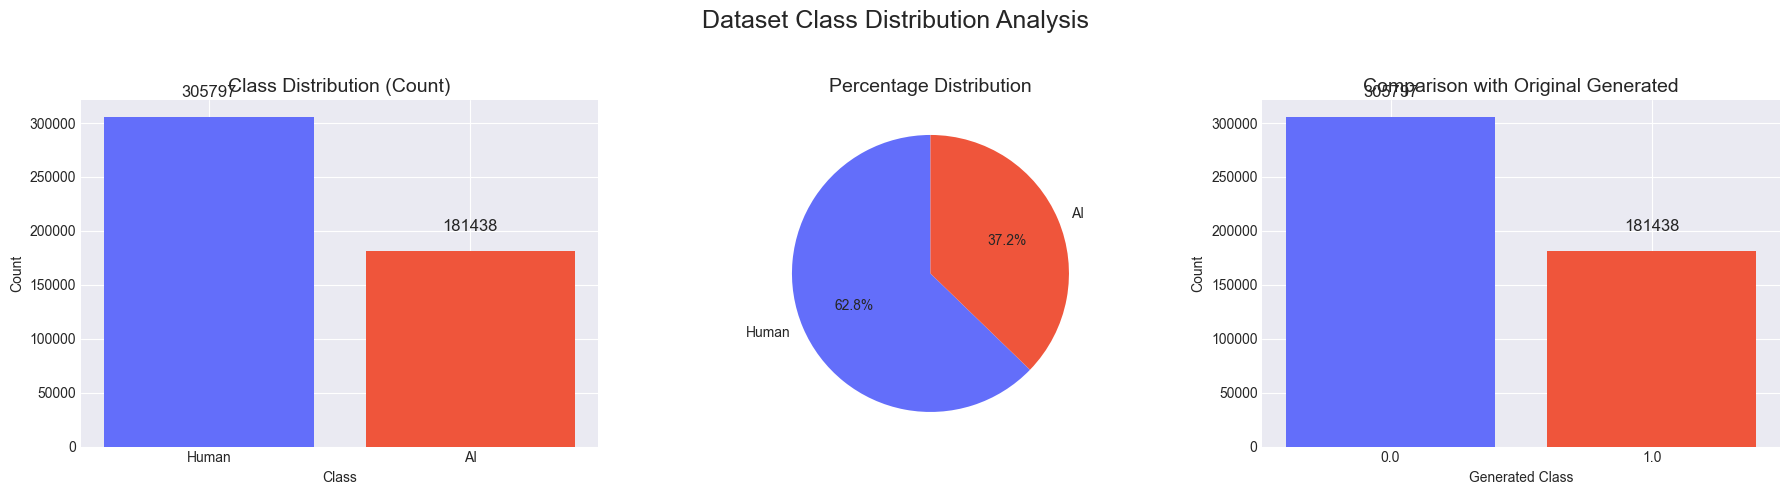

In [7]:
import matplotlib.pyplot as plt

color_palette = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

class_counts = df['label'].value_counts()
generated_counts = df['generated'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Bar chart for class distribution 
axes[0].bar(class_counts.index, class_counts.values, color=color_palette[:len(class_counts)])
for i, val in enumerate(class_counts.values):
    axes[0].text(i, val + 0.05*max(class_counts.values), str(val), ha='center', va='bottom', fontsize=12)
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

#  Pie chart for class percentage ---
axes[1].pie(class_counts.values, labels=class_counts.index, colors=color_palette[:len(class_counts)],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage Distribution', fontsize=14)

#  Bar chart for generated comparison ---
axes[2].bar(generated_counts.index.astype(str), generated_counts.values, color=color_palette[:len(generated_counts)])
for i, val in enumerate(generated_counts.values):
    axes[2].text(i, val + 0.05*max(generated_counts.values), str(val), ha='center', va='bottom', fontsize=12)
axes[2].set_title('Comparison with Original Generated', fontsize=14)
axes[2].set_xlabel('Generated Class')
axes[2].set_ylabel('Count')

plt.suptitle('Dataset Class Distribution Analysis', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

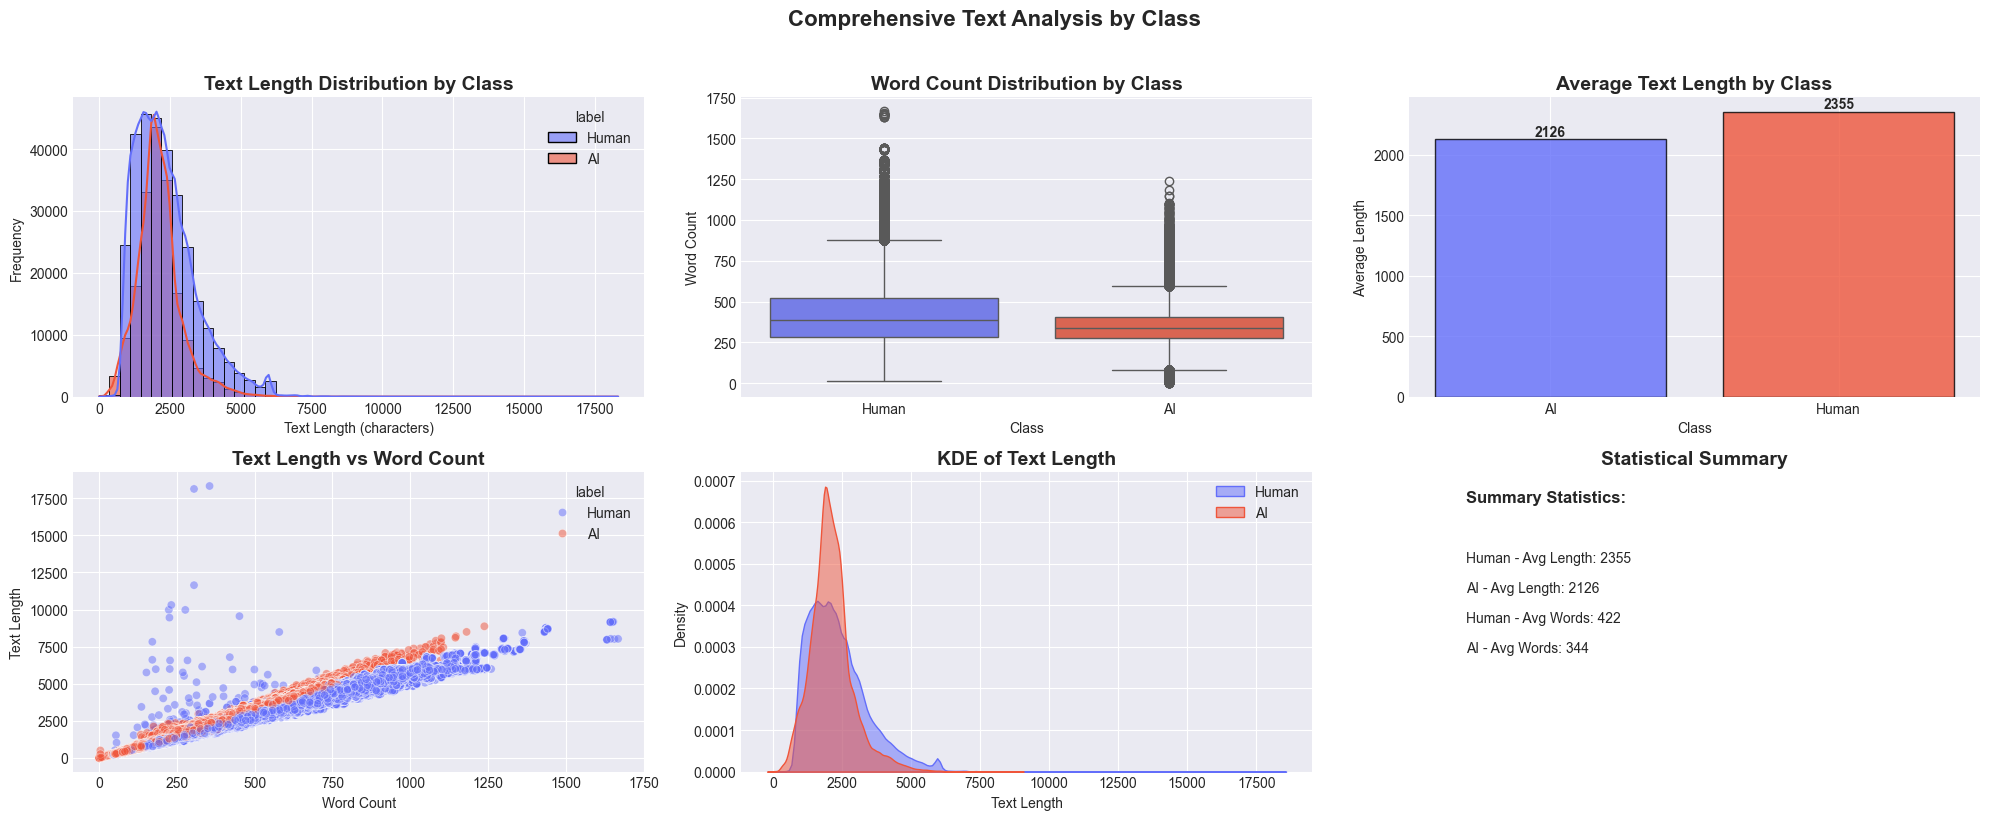

In [8]:
#  Text Length Analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig = plt.figure(figsize=(20, 8))

#  Text Length Distribution
plt.subplot(2, 3, 1)
sns.histplot(data=df, x='text_length', hue='label', 
             kde=True, palette=color_palette[:2], alpha=0.6, bins=50)
plt.title('Text Length Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')

#  Word Count Distribution
plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='label', y='word_count', 
            palette=color_palette[:2])
plt.title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Word Count')

#  Average Text Length Comparison
plt.subplot(2, 3, 3)
avg_length = df.groupby('label')['text_length'].mean()
bars = plt.bar(avg_length.index, avg_length.values, 
               color=color_palette[:2], edgecolor='black', alpha=0.8)
plt.title('Average Text Length by Class', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Average Length')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

#  Text Length vs Word Count
plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='word_count', y='text_length', 
                hue='label', alpha=0.5, palette=color_palette[:2])
plt.title('Text Length vs Word Count', fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Text Length')

#  Distribution of Text Length (KDE)
plt.subplot(2, 3, 5)
sns.kdeplot(data=df[df['label'] == 'Human']['text_length'], 
            label='Human', fill=True, color=color_palette[0], alpha=0.5)
sns.kdeplot(data=df[df['label'] == 'AI']['text_length'], 
            label='AI', fill=True, color=color_palette[1], alpha=0.5)
plt.title('KDE of Text Length', fontsize=14, fontweight='bold')
plt.xlabel('Text Length')
plt.ylabel('Density')
plt.legend()

#  Summary Statistics
plt.subplot(2, 3, 6)
stats_df = df.groupby('label').agg({
    'text_length': ['mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median', 'std']
}).round(2)

plt.text(0.1, 0.9, 'Summary Statistics:', fontsize=12, fontweight='bold')
plt.text(0.1, 0.7, f"Human - Avg Length: {stats_df.loc['Human', ('text_length', 'mean')]:.0f}", fontsize=10)
plt.text(0.1, 0.6, f"AI - Avg Length: {stats_df.loc['AI', ('text_length', 'mean')]:.0f}", fontsize=10)
plt.text(0.1, 0.5, f"Human - Avg Words: {stats_df.loc['Human', ('word_count', 'mean')]:.0f}", fontsize=10)
plt.text(0.1, 0.4, f"AI - Avg Words: {stats_df.loc['AI', ('word_count', 'mean')]:.0f}", fontsize=10)
plt.axis('off')
plt.title('Statistical Summary', fontsize=14, fontweight='bold')

plt.suptitle('Comprehensive Text Analysis by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Text Preprocessing</span>
</div>

In [9]:
# Initialize NLP tools
print(" Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-eng', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing function
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = re.sub(r'<.*?>', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

print(" Starting text preprocessing...")
print(f"Total texts to process: {len(df)}")

batch_size = 50000
cleaned_texts = []

for i in range(0, len(df), batch_size):
    batch = df['text'].iloc[i:i+batch_size]
    cleaned_batch = batch.apply(preprocess_text)
    cleaned_texts.extend(cleaned_batch)
    
    progress = min(i + batch_size, len(df))
    print(f"  Processed {progress}/{len(df)} texts ({progress/len(df)*100:.1f}%)")

df['cleaned_text'] = cleaned_texts

original_len = df['text'].str.len().mean()
cleaned_len = df['cleaned_text'].str.len().mean()
original_words = df['text'].apply(lambda x: len(str(x).split())).mean()
cleaned_words = df['cleaned_text'].apply(lambda x: len(str(x).split())).mean()

print("\n" + "=" * 60)
print("PREPROCESSING RESULTS")
print("=" * 60)
print(f"Average text length:")
print(f"  Original: {original_len:.0f} characters")
print(f"  Cleaned: {cleaned_len:.0f} characters")
print(f"  Reduction: {((original_len - cleaned_len)/original_len)*100:.1f}%")

print(f"\nAverage word count:")
print(f"  Original: {original_words:.0f} words")
print(f"  Cleaned: {cleaned_words:.0f} words")
print(f"  Reduction: {((original_words - cleaned_words)/original_words)*100:.1f}%")

# Show sample of processed text
print("\n" + "=" * 80)
print("SAMPLE OF ORIGINAL VS CLEANED TEXT")
print("=" * 80)

sample_indices = np.random.choice(len(df), 3, replace=False)
for idx in sample_indices:
    print(f"\n Sample #{list(sample_indices).index(idx) + 1} ({df['label'].iloc[idx]}):")
    print(f"\nOriginal (first 300 chars):")
    print(f"{df['text'].iloc[idx][:300]}...")
    print(f"\nCleaned:")
    print(f"{df['cleaned_text'].iloc[idx][:300]}..." if len(df['cleaned_text'].iloc[idx]) > 300 
          else df['cleaned_text'].iloc[idx])
    print("-" * 80)

 Starting text preprocessing...
Total texts to process: 487235


[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


  Processed 50000/487235 texts (10.3%)
  Processed 100000/487235 texts (20.5%)
  Processed 150000/487235 texts (30.8%)
  Processed 200000/487235 texts (41.0%)
  Processed 250000/487235 texts (51.3%)
  Processed 300000/487235 texts (61.6%)
  Processed 350000/487235 texts (71.8%)
  Processed 400000/487235 texts (82.1%)
  Processed 450000/487235 texts (92.4%)
  Processed 487235/487235 texts (100.0%)

PREPROCESSING RESULTS
Average text length:
  Original: 2270 characters
  Cleaned: 1427 characters
  Reduction: 37.1%

Average word count:
  Original: 393 words
  Cleaned: 201 words
  Reduction: 48.8%

SAMPLE OF ORIGINAL VS CLEANED TEXT

 Sample #1 (Human):

Original (first 300 chars):
Dear Senator,

I think we should keep the Electoral College because it gives the people opportunities to Vote for electors AOD presidents. If we Vote for popular Notes Theo that doe sot mean people truly know what president they wait to run their country. Who we Vote we are actually choosing our ele...

Cleaned:

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Feature Engineering</span>
</div>

In [10]:
print(" Creating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,  
    ngram_range=(1, 3),  
    min_df=10,           
    max_df=0.8,          
    stop_words='english',
    sublinear_tf=True,   
    smooth_idf=True      
)

X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])
print(f" TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f" Number of Features: {X_tfidf.shape[1]}")

feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n" + "=" * 60)
print("TOP FEATURES ANALYSIS")
print("=" * 60)

human_indices = df[df['label'] == 'Human'].index
ai_indices = df[df['label'] == 'AI'].index

human_avg_tfidf = np.asarray(X_tfidf[human_indices].mean(axis=0)).ravel()
ai_avg_tfidf = np.asarray(X_tfidf[ai_indices].mean(axis=0)).ravel()

top_human_idx = np.argsort(human_avg_tfidf)[::-1][:15]
print("\n Top 15 features for HUMAN text:")
for idx in top_human_idx:
    print(f"  {feature_names[idx]:20} Score: {human_avg_tfidf[idx]:.4f}")

top_ai_idx = np.argsort(ai_avg_tfidf)[::-1][:15]
print("\n Top 15 features for AI text:")
for idx in top_ai_idx:
    print(f"  {feature_names[idx]:20} Score: {ai_avg_tfidf[idx]:.4f}")

diff_tfidf = np.abs(human_avg_tfidf - ai_avg_tfidf)
top_diff_idx = np.argsort(diff_tfidf)[::-1][:20]

print("\n Top 20 most discriminative features:")
for idx in top_diff_idx[:20]:
    human_score = human_avg_tfidf[idx]
    ai_score = ai_avg_tfidf[idx]
    diff = abs(human_score - ai_score)
    class_pref = "Human" if human_score > ai_score else "AI"
    print(f"  {feature_names[idx]:25} Diff: {diff:.4f} (Prefers: {class_pref})")

 Creating TF-IDF features...
 TF-IDF Matrix Shape: (487235, 10000)
 Number of Features: 10000

TOP FEATURES ANALYSIS

 Top 15 features for HUMAN text:
  student              Score: 0.0329
  people               Score: 0.0320
  car                  Score: 0.0287
  school               Score: 0.0272
  like                 Score: 0.0251
  think                Score: 0.0248
  time                 Score: 0.0229
  thing                Score: 0.0228
  make                 Score: 0.0217
  help                 Score: 0.0215
  want                 Score: 0.0211
  good                 Score: 0.0201
  know                 Score: 0.0201
  way                  Score: 0.0196
  state                Score: 0.0185

 Top 15 features for AI text:
  student              Score: 0.0262
  important            Score: 0.0239
  help                 Score: 0.0215
  people               Score: 0.0203
  life                 Score: 0.0203
  time                 Score: 0.0182
  make                 Score: 0.0181
  le

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Train-Test Split</span>
</div>

DATA PREPARATION FOR MODELING
Label mapping: {'AI': np.int64(0), 'Human': np.int64(1)}
Original labels: ['AI' 'Human']

 Dataset Split Information:
----------------------------------------
Total samples: 487235
Training set: 341064 samples (70.0%)
Validation set: 48724 samples (10.0%)
Testing set: 97447 samples (20.0%)
Number of features: 10000

 Class Distribution:
----------------------------------------


,Human,AI,Total,Human %,AI %
Train,127006,214058,341064,37.2,62.8
Validation,18144,30580,48724,37.2,62.8
Test,36288,61159,97447,37.2,62.8


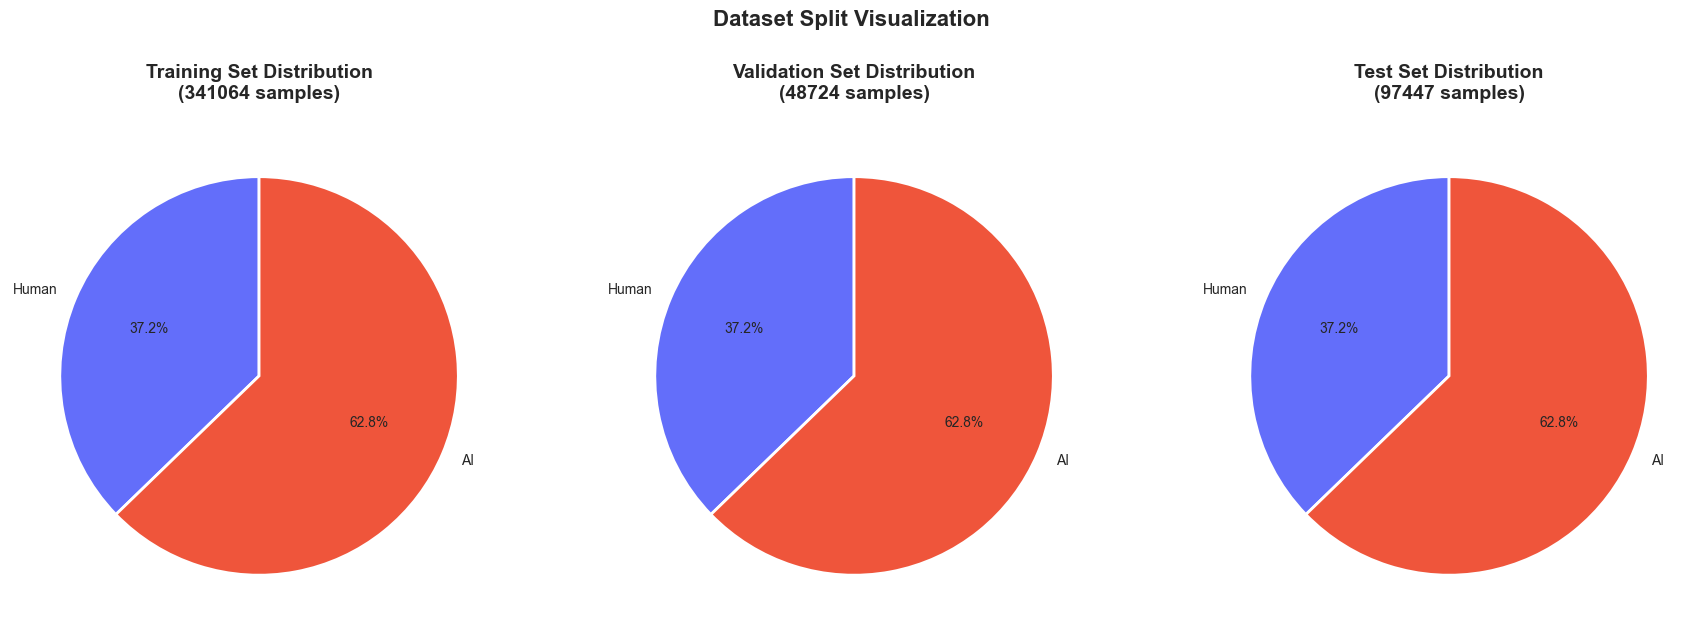

In [11]:
# Prepare data
X = X_tfidf
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)
print(f"Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Original labels: {label_encoder.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print("\n Dataset Split Information:")
print("-" * 40)
print(f"Total samples: {X.shape[0]}")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

print("\n Class Distribution:")
print("-" * 40)
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
}).T
dist_df.columns = ['Human', 'AI']
dist_df['Total'] = dist_df.sum(axis=1)
dist_df['Human %'] = (dist_df['Human'] / dist_df['Total'] * 100).round(1)
dist_df['AI %'] = (dist_df['AI'] / dist_df['Total'] * 100).round(1)

display(dist_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, counts, ax) in enumerate(zip(['Training', 'Validation', 'Test'],
                                             [train_counts, val_counts, test_counts],
                                             axes)):
    ax.pie(counts.values, labels=['Human', 'AI'], 
           colors=color_palette[:2], autopct='%1.1f%%',
           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(f'{name} Set Distribution\n({counts.sum()} samples)', 
                fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Dataset Split Visualization', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">Create Custom Test Examples</span>
</div>

In [12]:

custom_examples = [
    {
        "text": "I woke up late this morning and rushed to get ready for work. The traffic was terrible, as usual. I stopped for coffee but the line was too long, so I had to skip it. My day just didn't start well at all.",
        "expected": "Human",
        "description": "Personal narrative with emotions and daily routine"
    },
    {
        "text": "So I was thinking about what to cook for dinner tonight, maybe some pasta with garlic bread. But then I remembered we're out of garlic. Ugh, guess I'll have to improvise or just order pizza instead.",
        "expected": "Human",
        "description": "Casual, conversational style with hesitation"
    },
    {
        "text": "The movie last night was okay, but the ending felt rushed. I mean, they spent two hours building up the characters and then wrapped everything up in five minutes. I expected more from that director.",
        "expected": "Human",
        "description": "Subjective opinion with criticism"
    },
    
    {
        "text": "The proliferation of artificial intelligence technologies has precipitated a paradigm shift in computational methodologies, thereby engendering novel approaches to problem-solving in diverse domains including healthcare, finance, and autonomous systems.",
        "expected": "AI",
        "description": "Formal, academic style with complex vocabulary"
    },
    {
        "text": "To optimize operational efficiency, organizations must implement robust data governance frameworks that ensure data quality, security, and compliance with regulatory requirements while facilitating data-driven decision-making processes.",
        "expected": "AI",
        "description": "Corporate/business jargon, structured"
    },
    {
        "text": "Climate change represents a significant global challenge that necessitates immediate action through international cooperation, policy interventions, and technological innovation to mitigate its adverse impacts on ecosystems and human societies.",
        "expected": "AI",
        "description": "Formal, structured, topic-focused"
    },
    
    {
        "text": "Once upon a time in a quaint little village nestled between rolling hills and lush forests, there lived an elderly artisan renowned for crafting exquisite wooden sculptures that seemed to capture the very essence of nature's beauty.",
        "expected": "Mixed",
        "description": "Creative writing, could be either"
    },
    {
        "text": "Hey there! Just wanted to check in and see how you've been doing lately. It's been ages since we last caught up! Work has been absolutely crazy - tons of deadlines and meetings back-to-back. Anyway, drop me a line when you get a chance!",
        "expected": "Human",
        "description": "Informal, personal communication"
    },
    {
        "text": "The quantum entanglement phenomenon, whereby pairs or groups of particles interact in such a manner that the quantum state of each particle cannot be described independently of the state of the others, remains a subject of extensive research in theoretical physics.",
        "expected": "AI",
        "description": "Scientific/technical explanation"
    },
    {
        "text": "OMG can you believe what happened yesterday? I was at the mall and ran into Sarah from high school! She looks exactly the same after all these years. We ended up grabbing coffee and chatting for like two hours. So crazy!",
        "expected": "Human",
        "description": "Very informal, emotional, with slang"
    }
]

custom_df = pd.DataFrame(custom_examples)
print(f"Created {len(custom_df)} custom examples for testing")
print("\nExample Types Distribution:")
print(custom_df['expected'].value_counts())

Created 10 custom examples for testing

Example Types Distribution:
expected
Human    5
AI       4
Mixed    1
Name: count, dtype: int64


<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;"> Preprocess Custom Examples</span>
</div>

In [13]:

custom_df['cleaned_text'] = custom_df['text'].apply(preprocess_text)

print("\n Preprocessing Statistics:")
for i, row in custom_df.iterrows():
    original_len = len(row['text'])
    cleaned_len = len(row['cleaned_text'])
    reduction = ((original_len - cleaned_len) / original_len * 100) if original_len > 0 else 0
    
    print(f"\nExample {i+1} ({row['description'][:30]}...):")
    print(f"  Original: {original_len} chars")
    print(f"  Cleaned: {cleaned_len} chars")
    print(f"  Reduction: {reduction:.1f}%")

print("\n" + "=" * 80)
print("CLEANED TEXT EXAMPLES")
print("=" * 80)
for i in range(min(9, len(custom_df))):
    print(f"\nExample {i+1} (Expected: {custom_df.iloc[i]['expected']}):")
    print(f"Original: {custom_df.iloc[i]['text'][:150]}...")
    print(f"Cleaned: {custom_df.iloc[i]['cleaned_text'][:150]}...")


 Preprocessing Statistics:

Example 1 (Personal narrative with emotio...):
  Original: 204 chars
  Cleaned: 107 chars
  Reduction: 47.5%

Example 2 (Casual, conversational style w...):
  Original: 198 chars
  Cleaned: 111 chars
  Reduction: 43.9%

Example 3 (Subjective opinion with critic...):
  Original: 198 chars
  Cleaned: 128 chars
  Reduction: 35.4%

Example 4 (Formal, academic style with co...):
  Original: 253 chars
  Cleaned: 215 chars
  Reduction: 15.0%

Example 5 (Corporate/business jargon, str...):
  Original: 236 chars
  Cleaned: 204 chars
  Reduction: 13.6%

Example 6 (Formal, structured, topic-focu...):
  Original: 244 chars
  Cleaned: 203 chars
  Reduction: 16.8%

Example 7 (Creative writing, could be eit...):
  Original: 232 chars
  Cleaned: 168 chars
  Reduction: 27.6%

Example 8 (Informal, personal communicati...):
  Original: 236 chars
  Cleaned: 130 chars
  Reduction: 44.9%

Example 9 (Scientific/technical explanati...):
  Original: 265 chars
  Cleaned: 189 chars
 

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">TRAIN YOURS HEREE</span>
</div>

In [17]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("=" * 60)
print("TRAINING LIGHTGBM MODEL")
print("=" * 60)

lgbm_model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='binary_logloss'
)

print("LightGBM training completed!")

y_val_pred = lgbm_model.predict(X_val)
y_val_prob = lgbm_model.predict_proba(X_val)[:, 1]

print("\nValidation Results:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_val_prob):.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))


TRAINING LIGHTGBM MODEL
[LightGBM] [Info] Number of positive: 214058, number of negative: 127006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.683882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2436651
[LightGBM] [Info] Number of data points in the train set: 341064, number of used features: 10000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.627618 -> initscore=0.522013
[LightGBM] [Info] Start training from score 0.522013
LightGBM training completed!

Validation Results:
----------------------------------------
Accuracy: 0.9992
ROC-AUC:  1.0000

Classification Report (Validation):
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00     18144
       Human       1.00      1.00      1.00     30580

    accuracy                           1.00     48724
   macro avg       1.00      1.00      1.00     48724
weighted avg       1.00      1.00      1.

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">TEST YOURS HEREE on Custom Examples</span>
</div>

In [19]:
print(f"\nTesting {len(custom_df)} custom examples with Logistic Regression...")
print("=" * 60)

correct_count = 0

for idx, example in custom_df.iterrows():
    cleaned = preprocess_text(example['text'])
    features = tfidf_vectorizer.transform([cleaned])
    prediction = lgbm_model.predict(features)[0]
    label = label_encoder.inverse_transform([prediction])[0]

    if hasattr(lgbm_model, "predict_proba"):
        proba = lgbm_model.predict_proba(features)[0]
        ai_index = list(label_encoder.classes_).index('AI')
        human_index = list(label_encoder.classes_).index('Human')
        ai_prob = proba[ai_index]
        human_prob = proba[human_index]
        confidence = max(proba)
    else:
        human_prob, ai_prob, confidence = 0.5, 0.5, 0.0

    correct = label == example['expected']
    if correct:
        correct_count += 1

    print(f"\nExample {idx+1}: {example['description']}")
    print(f"Text: {example['text'][:80]}...")
    print(f"Expected: {example['expected']}")
    print(f"Predicted: {label} (Confidence: {confidence:.1%})")
    print(f"Human Probability: {human_prob:.1%}, AI Probability: {ai_prob:.1%}")
    print(f"Result: {'✓' if correct else '✗'}")

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"\nLogistic Regression Accuracy: {correct_count/len(custom_df):.1%} ({correct_count}/{len(custom_df)} correct)")


Testing 10 custom examples with Logistic Regression...

Example 1: Personal narrative with emotions and daily routine
Text: I woke up late this morning and rushed to get ready for work. The traffic was te...
Expected: Human
Predicted: AI (Confidence: 97.5%)
Human Probability: 2.5%, AI Probability: 97.5%
Result: ✗

Example 2: Casual, conversational style with hesitation
Text: So I was thinking about what to cook for dinner tonight, maybe some pasta with g...
Expected: Human
Predicted: AI (Confidence: 95.2%)
Human Probability: 4.8%, AI Probability: 95.2%
Result: ✗

Example 3: Subjective opinion with criticism
Text: The movie last night was okay, but the ending felt rushed. I mean, they spent tw...
Expected: Human
Predicted: AI (Confidence: 99.8%)
Human Probability: 0.2%, AI Probability: 99.8%
Result: ✗

Example 4: Formal, academic style with complex vocabulary
Text: The proliferation of artificial intelligence technologies has precipitated a par...
Expected: AI
Predicted: AI (Confidence

<div style="text-align: center; margin: 20px 0;">
    <span style="color: #8B0000; font-weight: bold; font-size: 30px;">MODEL PERFORMANCE ANALYSIS FOR YOURS HERE</span>
</div>


Evaluating LightGBM on test set...

 Test Set Performance:
Accuracy: 0.9994
F1 Score: 0.9994

 Classification Report:
              precision    recall  f1-score   support

          AI       1.00      1.00      1.00     36288
       Human       1.00      1.00      1.00     61159

    accuracy                           1.00     97447
   macro avg       1.00      1.00      1.00     97447
weighted avg       1.00      1.00      1.00     97447

 Confusion Matrix:


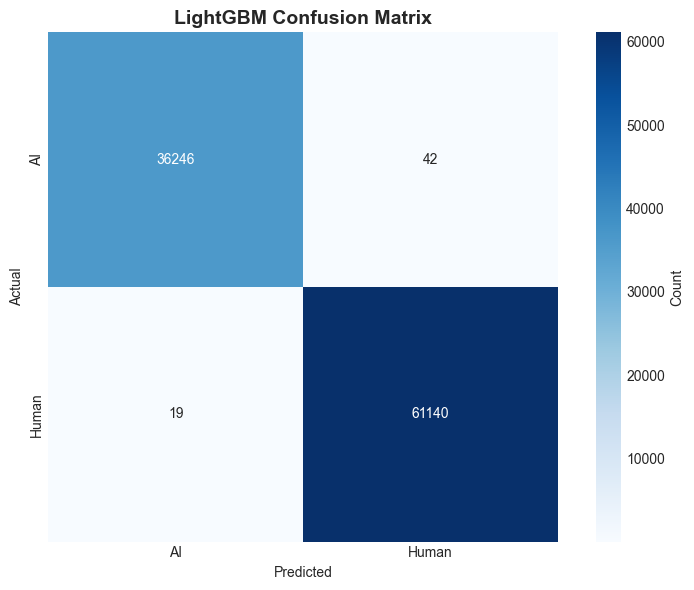


 Top Features for Classification:
  like                 importance: 166.0000
  school               importance: 164.0000
  student              importance: 161.0000
  people               importance: 132.0000
  conclusion           importance: 121.0000
  additionally         importance: 112.0000
  driving              importance: 106.0000
  think                importance: 102.0000
  reason               importance: 101.0000
  important            importance: 100.0000


In [18]:
print("\nEvaluating LightGBM on test set...")
y_test_pred = lgbm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n Test Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, 
                           target_names=label_encoder.classes_))

print(" Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, 
                     index=label_encoder.classes_,
                     columns=label_encoder.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            square=True, cbar_kws={'label': 'Count'})
plt.title('LightGBM Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n Top Features for Classification:")
feature_names = tfidf_vectorizer.get_feature_names_out()

feature_importance = lgbm_model.feature_importances_
top_idx = np.argsort(feature_importance)[-10:][::-1]

for idx in top_idx:
    print(f"  {feature_names[idx]:20} importance: {feature_importance[idx]:.4f}")
